# Description: Scan-Level CPM Results | Supplementary Figure 4

This notebook loads the result of running 100 iterations of the **scan-level** CPM algorithm on real data, and also those of running 10,000 iterations with randomized labels (null distribution).

Using these data, the notebook then computes non-parametric p-values for each prediction.

Finally, the notebook generates summary figures for the ability of CPM to predict experiential variables.

> **NOTE:** Although the notebook loads and computes values for the three CPM models (pos, neg and glm), ultimately on the paper we only report results for the glm case.

In [1]:
import pandas as pd
import os.path as osp
from utils.basics import RESOURCES_CPM_DIR
import hvplot.pandas
from tqdm.notebook import tqdm
import numpy as np
import pickle
from utils.basics import FB_400ROI_ATLAS_NAME
from cpm.plotting import plot_predictions
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import xarray as xr
from statsmodels.stats.multitest import multipletests

mkdir -p failed for path /path/to/your/new/cache/matplotlib: [Errno 13] Permission denied: '/path'
Matplotlib created a temporary cache directory at /tmp/matplotlib-bewp40a3 because there was an issue with the default path (/path/to/your/new/cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
print('hvplot version: %s' % str(hvplot.__version__))
print('xr version: %s' % str(xr.__version__))
print('pandas version: %s' % str(pd.__version__))

hvplot version: 0.12.1
xr version: 2024.11.0
pandas version: 2.3.2


In [3]:
ACCURACY_METRIC      = 'pearson'
CORR_TYPE            = 'pearson'
E_SUMMARY_METRIC     = 'sum'
CONFOUNDS            = 'conf_residualized'
# How Behaviors are encoded so far
BEHAVIOR_LIST        = ['Factor1','Factor2','Vigilance','Images','Words','People','Myself','Positive','Negative','Surroundings','Intrusive','Future','Past','Specific']
# New labels for consistency with text descriptions
BEHAVIOR_LABELS_DICT = {'Factor1':'Thought Pattern 1','Factor2':'Thought Pattern 2','Vigilance':'Wakefulness',
                        'Images':'Images','Words':'Words','People':'People','Myself':'Myself','Positive':'Positive','Negative':'Negative','Surroundings':'Surroundings','Intrusive':'Intrusive','Future':'Future','Past':'Past','Specific':'Specific'}
BEHAVIOR_LABELS      = ['Thought Pattern 1','Thought Pattern 2','Wakefulness','Images','Words','People','Myself','Positive','Negative','Surroundings','Intrusive','Future','Past','Specific']
# Mode used for running CPM
SPLIT_MODE           = 'basic'
# Atlas Selection
ATLAS                = FB_400ROI_ATLAS_NAME

***
# 1. Load CPM results

## 1.1. Real data

In [4]:
%%time
real_results_path = osp.join(RESOURCES_CPM_DIR,f'real-{ATLAS}-{SPLIT_MODE}-{CONFOUNDS}-{CORR_TYPE}_{E_SUMMARY_METRIC}.pkl')
print('++ INFO: Loading real predictions from: %s' % real_results_path)
with open(real_results_path,'rb') as f:
     real_predictions_xr = pickle.load(f)
Nbehavs, Niters_real, Nscans, Nresults = real_predictions_xr.shape
print('++ INFO: Shape of real predictions: Num Targets=%d, Num Iterations=%d, Num Scans=%d, Num Vars=%d' % (Nbehavs, Niters_real, Nscans, Nresults))

++ INFO: Loading real predictions from: /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/cpm/real-Schaefer2018_400Parcels_7Networks_AAL2-basic-conf_residualized-pearson_sum.pkl
++ INFO: Shape of real predictions: Num Targets=14, Num Iterations=100, Num Scans=469, Num Vars=4
CPU times: user 756 μs, sys: 26.8 ms, total: 27.6 ms
Wall time: 26.7 ms


Updating Behavior coordinate dimensions for proper labeling of final figures so that they agree with the main text

In [6]:
real_predictions_xr = real_predictions_xr.assign_coords({'Behavior':[BEHAVIOR_LABELS_DICT[b] for b in real_predictions_xr.Behavior.values]})

## 1.2. Randomized data

In [7]:
%%time
null_results_path = osp.join(RESOURCES_CPM_DIR,f'null-{ATLAS}-{SPLIT_MODE}-{CONFOUNDS}-{CORR_TYPE}_{E_SUMMARY_METRIC}.pkl')
print('++ INFO: Loading null predictions from: %s' % null_results_path)
with open(null_results_path,'rb') as f:
     null_predictions_xr = pickle.load(f)
_, Niters_null, _, _ = null_predictions_xr.shape
print('++ INFO: Shape of null predictions: Num Targets=%d, Num Iterations=%d, Num Scans=%d, Num Vars=%d' % (Nbehavs, Niters_null, Nscans, Nresults))

++ INFO: Loading null predictions from: /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/cpm/null-Schaefer2018_400Parcels_7Networks_AAL2-basic-conf_residualized-pearson_sum.pkl
++ INFO: Shape of null predictions: Num Targets=14, Num Iterations=10000, Num Scans=469, Num Vars=4
CPU times: user 0 ns, sys: 2.85 s, total: 2.85 s
Wall time: 3.13 s


In [8]:
null_predictions_xr = null_predictions_xr.assign_coords({'Behavior':[BEHAVIOR_LABELS_DICT[b] for b in null_predictions_xr.Behavior.values]})

***
# 2. Compute accuracy

## 2.1. Real data

In [9]:
%%time
accuracy_real          = {BEHAVIOR:pd.DataFrame(index=range(Niters_real), columns=['Accuracy']) for BEHAVIOR in BEHAVIOR_LABELS}

p_values          = pd.DataFrame(index=BEHAVIOR_LABELS,columns=['Non Parametric','Parametric'])

for BEHAVIOR in BEHAVIOR_LABELS:
    for niter in tqdm(range(Niters_real), desc=BEHAVIOR):
        observed  = pd.Series(real_predictions_xr.loc[BEHAVIOR,niter,:,'observed'].values)
        if E_SUMMARY_METRIC == 'ridge':
            predicted = pd.Series(real_predictions_xr.loc[BEHAVIOR,niter,:,'predicted (ridge)'].values)
        else:
            predicted = pd.Series(real_predictions_xr.loc[BEHAVIOR,niter,:,'predicted (glm)'].values)
        accuracy_real[BEHAVIOR].loc[niter]  = observed.corr(predicted, method='pearson')
        _,p_values.loc[BEHAVIOR,'Parametric'] = pearsonr(observed,predicted)

Thought Pattern 1:   0%|          | 0/100 [00:00<?, ?it/s]

Thought Pattern 2:   0%|          | 0/100 [00:00<?, ?it/s]

Wakefulness:   0%|          | 0/100 [00:00<?, ?it/s]

Images:   0%|          | 0/100 [00:00<?, ?it/s]

Words:   0%|          | 0/100 [00:00<?, ?it/s]

...

Intrusive:   0%|          | 0/100 [00:00<?, ?it/s]

Future:   0%|          | 0/100 [00:00<?, ?it/s]

Past:   0%|          | 0/100 [00:00<?, ?it/s]

Specific:   0%|          | 0/100 [00:00<?, ?it/s]

CPU times: user 2.24 s, sys: 96 ms, total: 2.34 s
Wall time: 2.36 s


Compute mean across all attemps

In [10]:
median_accuracies = pd.DataFrame(columns=['Pearson R'], index=BEHAVIOR_LABELS)
for BEHAVIOR in BEHAVIOR_LABELS:
    median_accuracies.loc[BEHAVIOR,'Pearson R'] = accuracy_real[BEHAVIOR].median().values[0]

In [11]:
median_accuracies_path = osp.join(RESOURCES_CPM_DIR,f'{SPLIT_MODE}_final_avg_accuracies.csv')
median_accuracies.to_csv(median_accuracies_path) 
print('++ INFO: Median accuracies saved to: %s' % median_accuracies_path)

++ INFO: Median accuracies saved to: /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/cpm/basic_final_avg_accuracies.csv


In [12]:
display(median_accuracies.infer_objects().round(2))

,Pearson R
Thought Pattern 1,0.42
Thought Pattern 2,0.40
Wakefulness,0.44
Images,0.37
Words,0.44
People,0.32
Myself,0.33
Positive,0.37
Negative,0.35
Surroundings,0.34


## 2.2. Null data

In [13]:
%%time
accuracy_null = {BEHAVIOR:pd.DataFrame(index=range(Niters_null), columns=['Accuracy']) for BEHAVIOR in BEHAVIOR_LABELS}
for BEHAVIOR in BEHAVIOR_LABELS:
    for niter in tqdm(range(Niters_null), desc=BEHAVIOR):
        observed  = pd.Series(null_predictions_xr.loc[BEHAVIOR,niter,:,'observed'].values)
        if E_SUMMARY_METRIC == 'ridge':
            predicted = pd.Series(null_predictions_xr.loc[BEHAVIOR,niter,:,'predicted (ridge)'].values)
        else:
            predicted = pd.Series(null_predictions_xr.loc[BEHAVIOR,niter,:,'predicted (glm)'].values)
        accuracy_null[BEHAVIOR].loc[niter]  = observed.corr(predicted, method=ACCURACY_METRIC)

Thought Pattern 1:   0%|          | 0/10000 [00:00<?, ?it/s]

Thought Pattern 2:   0%|          | 0/10000 [00:00<?, ?it/s]

Wakefulness:   0%|          | 0/10000 [00:00<?, ?it/s]

Images:   0%|          | 0/10000 [00:00<?, ?it/s]

Words:   0%|          | 0/10000 [00:00<?, ?it/s]

...

Intrusive:   0%|          | 0/10000 [00:00<?, ?it/s]

Future:   0%|          | 0/10000 [00:00<?, ?it/s]

Past:   0%|          | 0/10000 [00:00<?, ?it/s]

Specific:   0%|          | 0/10000 [00:00<?, ?it/s]

CPU times: user 2min 31s, sys: 9.58 s, total: 2min 41s
Wall time: 2min 41s


***
# 3. Compute non-parameter p-values

For this, we rely on the null distribution generated via label randomization. 

We use the formula on section 2.4.4 from Finn & Bandettini ["Movie-watching outperforms rest for functional connectivity-based prediction of behavior"](https://www.sciencedirect.com/science/article/pii/S1053811921002408) NeuroImage 2021

In [14]:
p_values.columns.name = 'p-value'
for BEHAVIOR in BEHAVIOR_LABELS:
    p_values.loc[BEHAVIOR,'Non Parametric'] = (((accuracy_null[BEHAVIOR] > accuracy_real[BEHAVIOR].median()).sum() + 1) / (Niters_null+1)).values[0]

Add values after correcting for multiple comparisons using FDR

In [15]:
(reject_bonf, p_values['Non Parametric, FDRbh'], _, _ ) = multipletests(p_values['Non Parametric'],alpha=0.05,method='fdr_bh')

In [16]:
with pd.option_context("display.float_format", lambda x: "%0.1e" % x):
    display(p_values.infer_objects()[['Parametric','Non Parametric','Non Parametric, FDRbh']])

p-value,Parametric,Non Parametric,"Non Parametric, FDRbh"
Thought Pattern 1,1.9e-21,1.0e-04,1.1e-04
Thought Pattern 2,9.8e-21,1.0e-04,1.1e-04
Wakefulness,7.0e-24,1.0e-04,1.1e-04
Images,2.2e-17,1.0e-04,1.1e-04
Words,1.2e-21,1.0e-04,1.1e-04
People,1.6e-11,1.0e-04,1.1e-04
Myself,1.2e-12,1.0e-04,1.1e-04
Positive,1.3e-15,1.0e-04,1.1e-04
Negative,4.8e-16,1.0e-04,1.1e-04
Surroundings,6.2e-14,1.0e-04,1.1e-04


***
# 4. Generate Prediction-reporting Figures

In [17]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [18]:
%%time
rows = []

for behavior in BEHAVIOR_LABELS:
    for i in tqdm(range(Niters_null), desc=behavior):
        r_value = accuracy_null[behavior].loc[i].values[0]

        rows.append({
            "Question": behavior,
            "Iteration": i,
            "R": r_value
        })

null_df = pd.DataFrame(rows, columns=["Question", "Iteration", "R"])

Thought Pattern 1:   0%|          | 0/10000 [00:00<?, ?it/s]

Thought Pattern 2:   0%|          | 0/10000 [00:00<?, ?it/s]

Wakefulness:   0%|          | 0/10000 [00:00<?, ?it/s]

Images:   0%|          | 0/10000 [00:00<?, ?it/s]

Words:   0%|          | 0/10000 [00:00<?, ?it/s]

...

Intrusive:   0%|          | 0/10000 [00:00<?, ?it/s]

Future:   0%|          | 0/10000 [00:00<?, ?it/s]

Past:   0%|          | 0/10000 [00:00<?, ?it/s]

Specific:   0%|          | 0/10000 [00:00<?, ?it/s]

CPU times: user 2.2 s, sys: 52.8 ms, total: 2.25 s
Wall time: 2.22 s


In [19]:
%%time
rows = []

for behavior in BEHAVIOR_LABELS:
    for i in tqdm(range(Niters_real), desc=behavior):
        rows.append({
            "Question": behavior,
            "Iteration": i,
            "R": accuracy_real[behavior].loc[i].values[0],
        })

real_df = pd.DataFrame(rows, columns=["Question", "Iteration", "R"])

Thought Pattern 1:   0%|          | 0/100 [00:00<?, ?it/s]

Thought Pattern 2:   0%|          | 0/100 [00:00<?, ?it/s]

Wakefulness:   0%|          | 0/100 [00:00<?, ?it/s]

Images:   0%|          | 0/100 [00:00<?, ?it/s]

Words:   0%|          | 0/100 [00:00<?, ?it/s]

...

Intrusive:   0%|          | 0/100 [00:00<?, ?it/s]

Future:   0%|          | 0/100 [00:00<?, ?it/s]

Past:   0%|          | 0/100 [00:00<?, ?it/s]

Specific:   0%|          | 0/100 [00:00<?, ?it/s]

CPU times: user 111 ms, sys: 11.7 ms, total: 123 ms
Wall time: 111 ms


We will now save these summary views to disk, as we will need them on the next notebook that creates a dashboard that allows a comprehensive exploration of the CPM results.

> **NOTE:** This file is used in S18 Dashboard to load results. If you don't run this cell when new CPM results are available, the Dashboard will present outdated results.

In [20]:
output_path = osp.join(RESOURCES_CPM_DIR,f'cpm_predictions_summary-{SPLIT_MODE}-{CONFOUNDS}-{CORR_TYPE}.pkl')
outputs     = {'real_df':real_df,'null_df':null_df, 'accuracy_real': accuracy_real, 'accuracy_null':accuracy_null, 'p_values':p_values, 'real_predictions_xr':real_predictions_xr, 'null_predictions_xr':null_predictions_xr}
with open(output_path ,'wb') as f:
    pickle.dump(outputs,f)
print('++ INFO: Data written to disk [%s]' % output_path)

++ INFO: Data written to disk [/data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/cpm/cpm_predictions_summary-basic-conf_residualized-pearson.pkl]


## 4.1. Without statistical annotations


In [21]:
median_width = 0.4
sns.set(style='whitegrid')

Text(0.5, 0, 'SNYCQ Item')

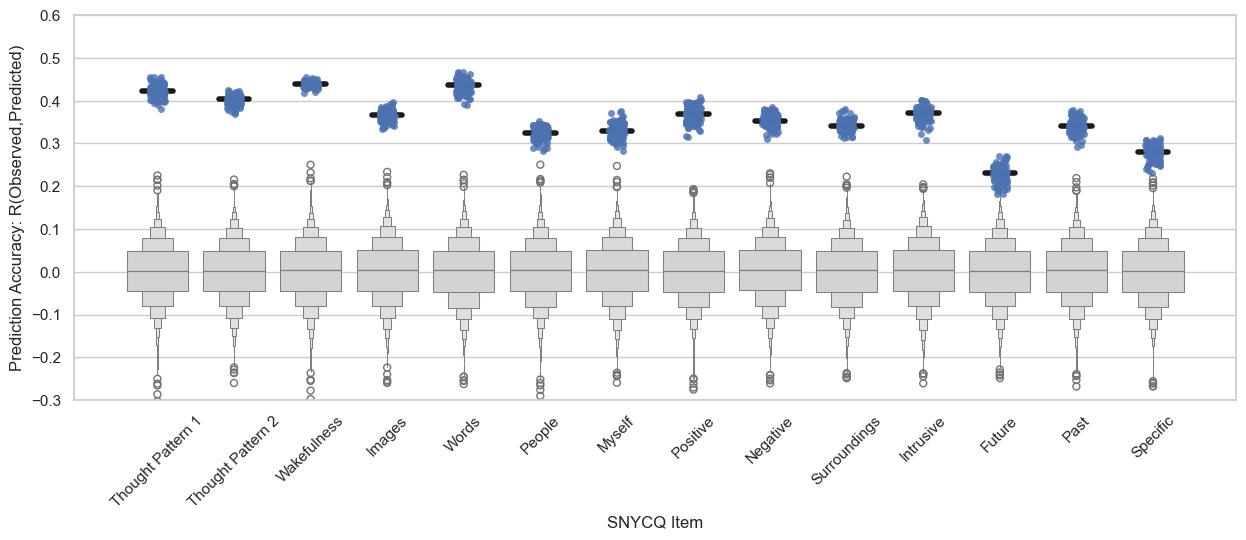

In [22]:
fig,ax = plt.subplots(1,1,figsize=(15,5))
sns.boxenplot(data=null_df,x='Question',y='R', color='lightgray', ax=ax) 
sns.stripplot(data=real_df,x='Question', y='R', alpha=.8, ax=ax)
plt.xticks(rotation=45);
for tick, text in zip(ax.get_xticks(), ax.get_xticklabels()):
    question   = text.get_text()
    median_val = accuracy_real[question].median().values[0]
    ax.plot([tick-median_width/2, tick+median_width/2],[median_val,median_val], lw=4, color='k')
ax.set_ylim(-.3,.6)
ax.set_ylabel('Prediction Accuracy: R(Observed,Predicted)');
ax.set_xlabel('SNYCQ Item')

## 4.2. With Statistical Annotations

Text(0.5, 0, 'SNYCQ Item')

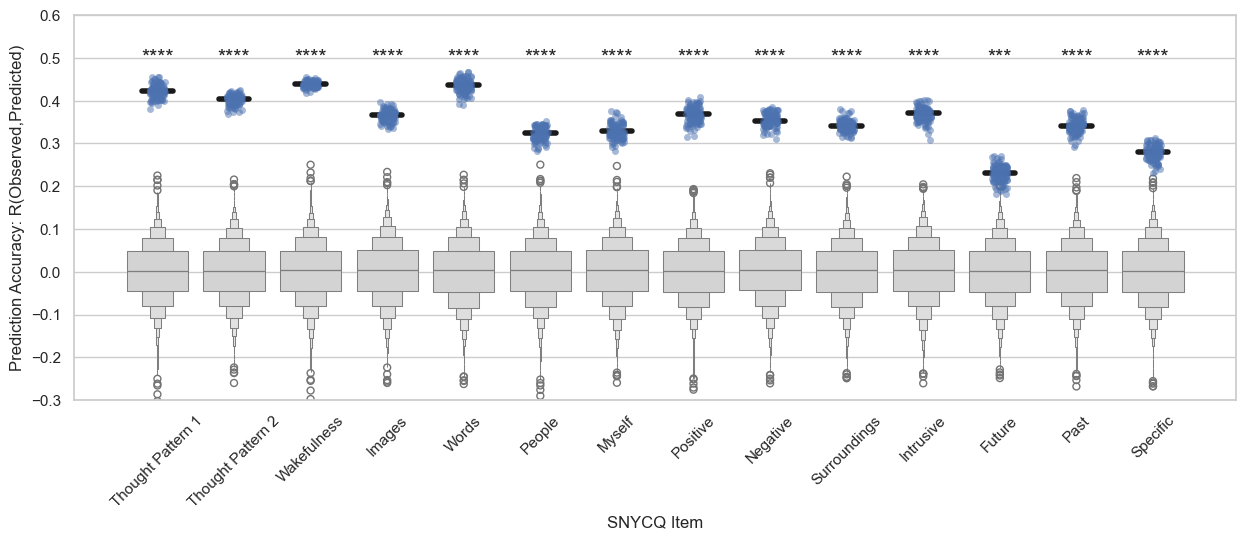

In [23]:
fig,ax = plt.subplots(1,1,figsize=(15,5))
sns.boxenplot(data=null_df,x='Question',y='R', color='lightgray', ax=ax) 
sns.stripplot(data=real_df,x='Question', y='R', alpha=.5, ax=ax)
plt.xticks(rotation=45);
for tick, text in zip(ax.get_xticks(), ax.get_xticklabels()):
    # Add Black Line Signaling Median
    question   = text.get_text()
    median_val = accuracy_real[question].median().values[0]
    ax.plot([tick-median_width/2, tick+median_width/2],[median_val,median_val], lw=4, color='k')
    # Statistical Significant Information
    p = p_values.loc[question,'Non Parametric']
    if 5.00e-02 < p <= 1.00e+00:
        annot = '' 
    elif 1.00e-02 < p <= 5.00e-02:
        annot = '*'
    elif 1.00e-03 < p <= 1.00e-02:
        annot = '**'
    elif 1.00e-04 < p <= 1.00e-03:
        annot = '***'
    elif p <= 1.00e-04:
        annot = '****'
    max_val = real_df.set_index('Question').max()['R']
    ax.annotate(annot, xy=(tick, max_val+0.02), ha='center', fontsize=15)
    
ax.set_ylim(-.3,.6)
ax.set_ylabel('Prediction Accuracy: R(Observed,Predicted)');
ax.set_xlabel('SNYCQ Item')

We will also plot the same results, but separated in three different panels. One for the wakefulness question, one for the two factors, and one for the 11 questions entering the Sparse Box-Constrained Non-Negative Matrix Factorization. This might come handy for presentations, yet it is exactly the same information as above.

Text(0, 0, 'Wakefulness') 0.44
Text(0, 0, 'Thought Pattern 1') 0.42
Text(1, 0, 'Thought Pattern 2') 0.40


/tmp/ipykernel_766294/1262533080.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Pattern 1','Pattern 2'])


Text(0, 0, 'Images') 0.37
Text(1, 0, 'Words') 0.44
Text(2, 0, 'People') 0.32
Text(3, 0, 'Myself') 0.33
Text(4, 0, 'Positive') 0.37
Text(5, 0, 'Negative') 0.35
Text(6, 0, 'Surroundings') 0.34
Text(7, 0, 'Intrusive') 0.37
Text(8, 0, 'Future') 0.23
Text(9, 0, 'Past') 0.34
Text(10, 0, 'Specific') 0.28


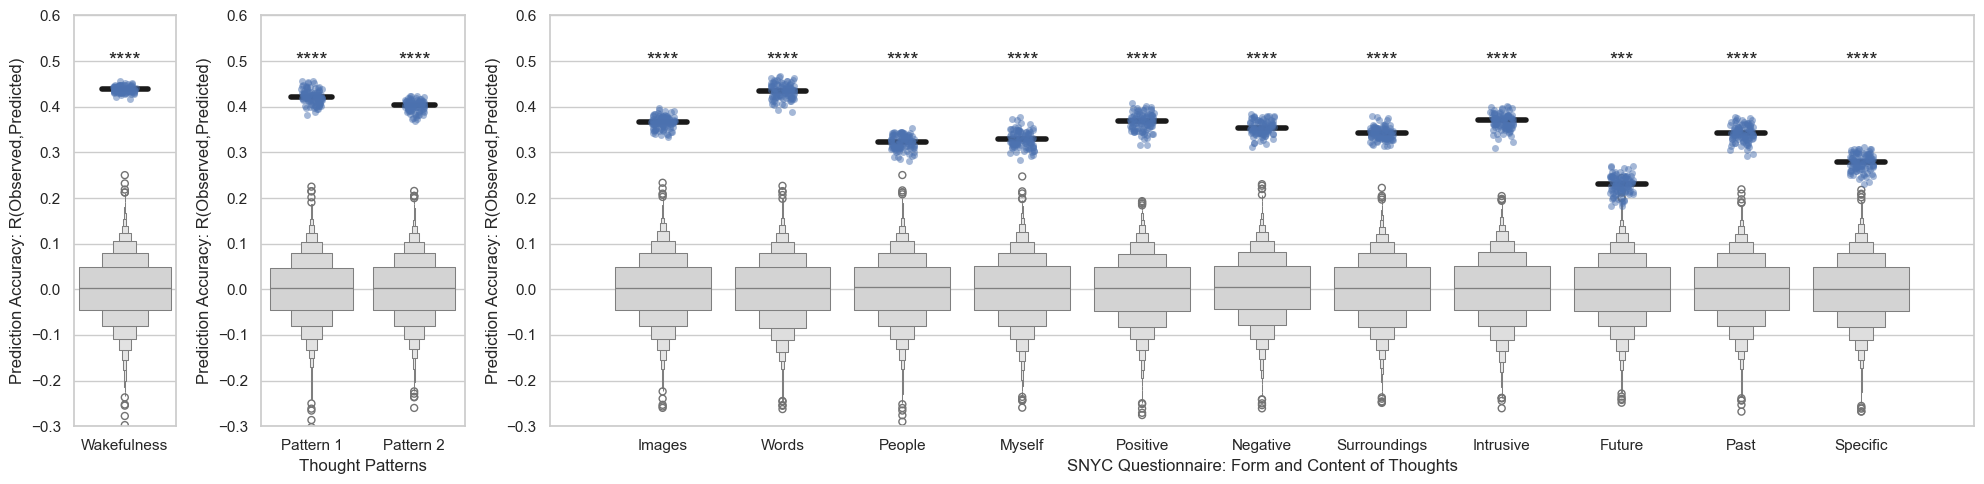

In [24]:
median_width = 0.4
sns.set(style='whitegrid')
fig,ax = plt.subplots(1,3 ,figsize=(20,5), gridspec_kw={'width_ratios': [1,2,14]})
# Vigilance
sns.boxenplot(data=null_df[null_df['Question']=='Wakefulness'],x='Question',y='R', color='lightgray', ax=ax[0]) 
sns.stripplot(data=real_df[real_df['Question']=='Wakefulness'],x='Question', y='R', alpha=.5, ax=ax[0])
for tick, text in zip(ax[0].get_xticks(), ax[0].get_xticklabels()):
    # Add Black Line Signaling Median
    question   = text.get_text()
    median_val = accuracy_real[question].median().values[0]
    print(text, '%.2f' % median_val)
    ax[0].plot([tick-median_width/2, tick+median_width/2],[median_val,median_val], lw=4, color='k')
    # Statistical Significant Information
    p = p_values.loc[question,'Non Parametric']
    if 5.00e-02 < p <= 1.00e+00:
        annot = '' 
    elif 1.00e-02 < p <= 5.00e-02:
        annot = '*'
    elif 1.00e-03 < p <= 1.00e-02:
        annot = '**'
    elif 1.00e-04 < p <= 1.00e-03:
        annot = '***'
    elif p <= 1.00e-04:
        annot = '****'
    max_val = real_df.set_index('Question').max()['R']
    ax[0].annotate(annot, xy=(tick, max_val+0.02), ha='center', fontsize=15)
    
ax[0].set_ylim(-.3,.6)
ax[0].set_ylabel('Prediction Accuracy: R(Observed,Predicted)');
ax[0].set_xlabel('')

# Factors
sns.boxenplot(data=null_df[(null_df['Question']=='Thought Pattern 1') | (null_df['Question']=='Thought Pattern 2')],x='Question', y='R', color='lightgray', ax=ax[1]) 
sns.stripplot(data=real_df[(real_df['Question']=='Thought Pattern 1') | (real_df['Question']=='Thought Pattern 2')],x='Question', y='R', alpha=.5, ax=ax[1])
for tick, text in zip(ax[1].get_xticks(), ax[1].get_xticklabels()):
    # Add Black Line Signaling Median
    question   = text.get_text()
    median_val = accuracy_real[question].median().values[0]
    print(text, '%.2f' % median_val)
    ax[1].plot([tick-median_width/2, tick+median_width/2],[median_val,median_val], lw=4, color='k')
    # Statistical Significant Information
    p = p_values.loc[question,'Non Parametric']
    if 5.00e-02 < p <= 1.00e+00:
        annot = '' 
    elif 1.00e-02 < p <= 5.00e-02:
        annot = '*'
    elif 1.00e-03 < p <= 1.00e-02:
        annot = '**'
    elif 1.00e-04 < p <= 1.00e-03:
        annot = '***'
    elif p <= 1.00e-04:
        annot = '****'
    max_val = real_df.set_index('Question').max()['R']
    ax[1].annotate(annot, xy=(tick, max_val+0.02), ha='center', fontsize=15)
ax[1].set_xticklabels(['Pattern 1','Pattern 2'])
ax[1].set_ylim(-.3,.6)
ax[1].set_ylabel('Prediction Accuracy: R(Observed,Predicted)');
ax[1].set_xlabel('Thought Patterns')

# Individual Iterms
sns.boxenplot(data=null_df[(null_df['Question']!='Thought Pattern 1') & (null_df['Question']!='Thought Pattern 2') & (null_df['Question']!='Wakefulness')],x='Question', y='R', color='lightgray', ax=ax[2]) 
sns.stripplot(data=real_df[(real_df['Question']!='Thought Pattern 1') & (real_df['Question']!='Thought Pattern 2') & (real_df['Question']!='Wakefulness')],x='Question', y='R', alpha=.5, ax=ax[2])
for tick, text in zip(ax[2].get_xticks(), ax[2].get_xticklabels()):
    # Add Black Line Signaling Median
    question   = text.get_text()
    median_val = accuracy_real[question].median().values[0]
    ax[2].plot([tick-median_width/2, tick+median_width/2],[median_val,median_val], lw=4, color='k')
    # Statistical Significant Information
    p = p_values.loc[question,'Non Parametric']
    if 5.00e-02 < p <= 1.00e+00:
        annot = '' 
    elif 1.00e-02 < p <= 5.00e-02:
        annot = '*'
        print(text, '%.2f' % median_val)
    elif 1.00e-03 < p <= 1.00e-02:
        annot = '**'
        print(text, '%.2f' % median_val)
    elif 1.00e-04 < p <= 1.00e-03:
        annot = '***'
        print(text, '%.2f' % median_val)
    elif p <= 1.00e-04:
        annot = '****'
        print(text, '%.2f' % median_val)
    max_val = real_df.set_index('Question').max()['R']
    ax[2].annotate(annot, xy=(tick, max_val+0.02), ha='center', fontsize=15)
    
ax[2].set_ylim(-.3,.6)
ax[2].set_ylabel('Prediction Accuracy: R(Observed,Predicted)');
ax[2].set_xlabel('SNYC Questionnaire: Form and Content of Thoughts')
plt.tight_layout()

In [25]:
fig.savefig('./figures/Supplementary_Figure04-ScanLevelCPMResults.png')

Text(0, 0, 'Wakefulness') 0.44
Text(0, 0, 'Thought Pattern 1') 0.42
Text(1, 0, 'Thought Pattern 2') 0.40
Text(0, 0, 'Images') 0.37
Text(1, 0, 'Surroundings') 0.34
Text(2, 0, 'Past') 0.34


/tmp/ipykernel_766294/1540785016.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Pattern 1','Pattern 2'])


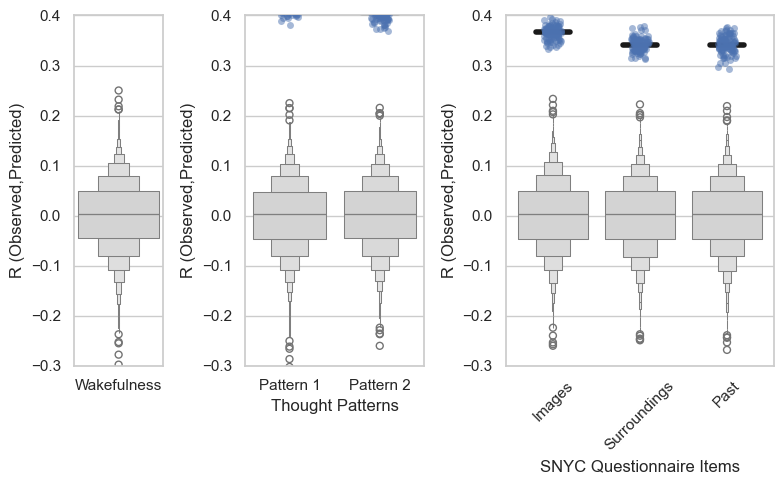

In [26]:
median_width = 0.4
sns.set(style='whitegrid')
fig,ax = plt.subplots(1,3 ,figsize=(8,5), gridspec_kw={'width_ratios': [1,2,3]})
# Vigilance
sns.boxenplot(data=null_df[null_df['Question']=='Wakefulness'],x='Question',y='R', color='lightgray', ax=ax[0]) 
sns.stripplot(data=real_df[real_df['Question']=='Wakefulness'],x='Question', y='R', alpha=.5, ax=ax[0])
plt.xticks(rotation=45);
for tick, text in zip(ax[0].get_xticks(), ax[0].get_xticklabels()):
    # Add Black Line Signaling Median
    question   = text.get_text()
    median_val = accuracy_real[question].median().values[0]
    print(text, '%.2f' % median_val)
    ax[0].plot([tick-median_width/2, tick+median_width/2],[median_val,median_val], lw=4, color='k')
    # Statistical Significant Information
    p = p_values.loc[question,'Non Parametric']
    if 5.00e-02 < p <= 1.00e+00:
        annot = '' 
    elif 1.00e-02 < p <= 5.00e-02:
        annot = '*'
    elif 1.00e-03 < p <= 1.00e-02:
        annot = '**'
    elif 1.00e-04 < p <= 1.00e-03:
        annot = '***'
    elif p <= 1.00e-04:
        annot = '****'
    max_val = real_df.set_index('Question').max()['R']
    ax[0].annotate(annot, xy=(tick, max_val+0.02), ha='center', fontsize=15)
    
ax[0].set_ylim(-.3,.4)
ax[0].set_ylabel('R (Observed,Predicted)');
ax[0].set_xlabel('')

# Factors
sns.boxenplot(data=null_df[(null_df['Question']=='Thought Pattern 1') | (null_df['Question']=='Thought Pattern 2')],x='Question',y='R', color='lightgray', ax=ax[1]) 
sns.stripplot(data=real_df[(real_df['Question']=='Thought Pattern 1') | (real_df['Question']=='Thought Pattern 2')],x='Question', y='R', alpha=.5, ax=ax[1])
plt.xticks(rotation=45);
for tick, text in zip(ax[1].get_xticks(), ax[1].get_xticklabels()):
    # Add Black Line Signaling Median
    question   = text.get_text()
    median_val = accuracy_real[question].median().values[0]
    print(text, '%.2f' % median_val)
    ax[1].plot([tick-median_width/2, tick+median_width/2],[median_val,median_val], lw=4, color='k')
    # Statistical Significant Information
    p = p_values.loc[question,'Non Parametric']
    if 5.00e-02 < p <= 1.00e+00:
        annot = '' 
    elif 1.00e-02 < p <= 5.00e-02:
        annot = '*'
    elif 1.00e-03 < p <= 1.00e-02:
        annot = '**'
    elif 1.00e-04 < p <= 1.00e-03:
        annot = '***'
    elif p <= 1.00e-04:
        annot = '****'
    max_val = real_df.set_index('Question').max()['R']
    ax[1].annotate(annot, xy=(tick, max_val+0.02), ha='center', fontsize=15)

ax[1].set_ylim(-.3,.4)
ax[1].set_xticklabels(['Pattern 1','Pattern 2'])
ax[1].set_ylabel('R (Observed,Predicted)');
ax[1].set_xlabel('Thought Patterns')

# Significant Individual Iterms
sns.boxenplot(data=null_df[(null_df['Question']=='Images') | (null_df['Question']=='Surroundings') | (null_df['Question']=='Past')],x='Question',y='R', color='lightgray', ax=ax[2]) 
sns.stripplot(data=real_df[(real_df['Question']=='Images') | (real_df['Question']=='Surroundings') | (real_df['Question']=='Past')],x='Question', y='R', alpha=.5, ax=ax[2])
plt.xticks(rotation=45);
for tick, text in zip(ax[2].get_xticks(), ax[2].get_xticklabels()):
    # Add Black Line Signaling Median
    question   = text.get_text()
    median_val = accuracy_real[question].median().values[0]
    ax[2].plot([tick-median_width/2, tick+median_width/2],[median_val,median_val], lw=4, color='k')
    # Statistical Significant Information
    p = p_values.loc[question,'Non Parametric']
    if 5.00e-02 < p <= 1.00e+00:
        annot = '' 
    elif 1.00e-02 < p <= 5.00e-02:
        annot = '*'
        print(text, '%.2f' % median_val)
    elif 1.00e-03 < p <= 1.00e-02:
        annot = '**'
        print(text, '%.2f' % median_val)
    elif 1.00e-04 < p <= 1.00e-03:
        annot = '***'
        print(text, '%.2f' % median_val)
    elif p <= 1.00e-04:
        annot = '****'
        print(text, '%.2f' % median_val)
    max_val = real_df.set_index('Question').max()['R']
    ax[2].annotate(annot, xy=(tick, max_val+0.02), ha='center', fontsize=15)
    
ax[2].set_ylim(-.3,.4)
ax[2].set_ylabel('R (Observed,Predicted)');
ax[2].set_xlabel('SNYC Questionnaire Items')
plt.tight_layout()

In [27]:
fig.savefig('./figures/Supplementary_Figure04-ScanLevelCPMResults_onlySignificant.png')

## 4.3. Scatter Plots of Observed vs. Predicted Values

In [28]:
N_sign_results = (p_values.loc[:,'Non Parametric'] < 0.05).sum()
print('++ INFO: Number of items predicted significantly: %d ' % N_sign_results)

++ INFO: Number of items predicted significantly: 14 


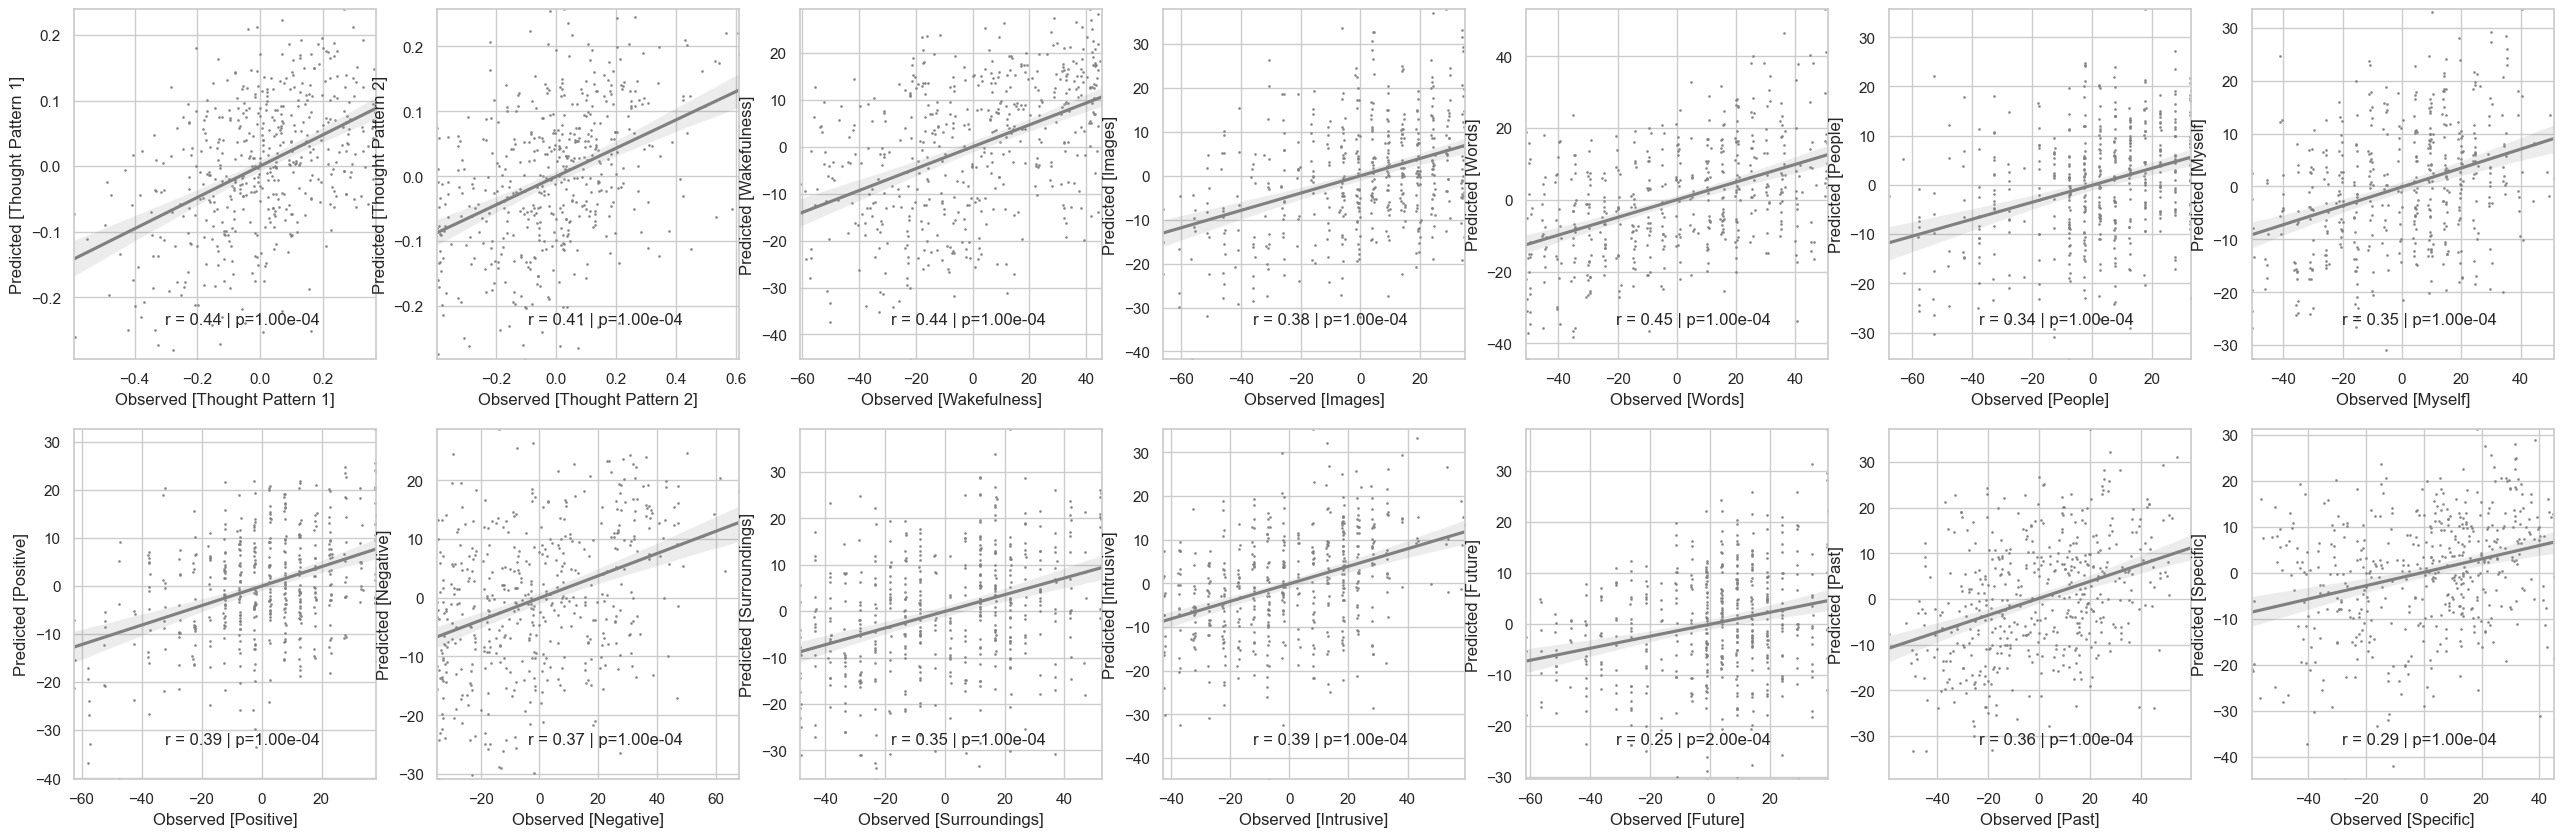

In [29]:
fig,ax = plt.subplots(2,int(N_sign_results/2),figsize=(32,10))
i = 0
for BEHAVIOR in BEHAVIOR_LABELS_DICT.values():
    p = p_values.loc[BEHAVIOR,'Non Parametric']
    if p <= 0.05:
        row,col        = np.unravel_index(i,(2,int(N_sign_results/2)))
        behav_obs_pred = pd.DataFrame(real_predictions_xr.median(dim='Iteration').loc[BEHAVIOR,:,['observed','predicted (glm)']], columns=['observed','predicted (glm)'])
        r,p = plot_predictions(behav_obs_pred, ax=ax[row,col], xlabel='Observed [%s]' % BEHAVIOR, ylabel='Predicted [%s]' % BEHAVIOR, font_scale=1,p_value=p_values.loc[BEHAVIOR,'Non Parametric'], 
                               ylim=(behav_obs_pred['predicted (glm)'].min(), behav_obs_pred['predicted (glm)'].max()),
                               xlim=(behav_obs_pred['observed'].min(), behav_obs_pred['observed'].max()))
        i= i + 1